<a href="https://colab.research.google.com/github/tfiorio/pos-pucrio/blob/spring02/MVP_Thompson_Fiorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Thompson Fiorio  
**Data:** 22/06/2026  
**Dataset:** Global EV Adoption Behavior 2026  
**Tipo de problema:** Classificação multiclasse  
**Variável-alvo:** `ev_adoption_likelihood`

---

Este notebook desenvolve um MVP de Machine Learning para prever a propensão de adoção de veículos elétricos a partir de fatores econômicos, comportamentais e de infraestrutura, com destaque para o gasto com combustível fóssil e a disponibilidade de estações de recarga.

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fallback local | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste | ✅ |
| Prevenção de vazamento de dados com `Pipeline` e `ColumnTransformer` | ✅ |
| Tratamentos de dados justificados | ✅ |
| Baseline e modelos candidatos treinados | ✅ |
| Otimização de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação em dados não vistos e conclusão crítica | ✅ |

# 1. Definição do problema

## 1.1 Descrição do problema

A transição de veículos a combustão para veículos elétricos depende de fatores econômicos, sociais, comportamentais e de infraestrutura. Entre esses fatores, dois pontos costumam ser especialmente relevantes:

1. o custo mensal associado a combustíveis fósseis, representado neste dataset por `fuel_expense_per_month`;
2. a disponibilidade e conveniência da infraestrutura de recarga, representada por variáveis como `charging_station_accessibility`, `nearest_charging_station_km` e `home_charging_available`.

O problema deste MVP é construir um modelo capaz de prever a propensão de adoção de veículos elétricos (`ev_adoption_likelihood`) a partir desses fatores e de outras características dos indivíduos, como renda, deslocamento, idade, conhecimento sobre veículos elétricos, afinidade tecnológica e consciência ambiental.

Essa solução poderia apoiar análises de mercado, políticas públicas, planejamento de infraestrutura de recarga e campanhas de incentivo à eletrificação da frota.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir, treinar e avaliar modelos de Machine Learning capazes de prever a classe de propensão de adoção de veículos elétricos — `Low`, `Medium` ou `High` — a partir de variáveis econômicas, comportamentais e de infraestrutura.

Além da previsão, o MVP busca analisar se fatores como gasto com combustível fóssil e acesso a estações de recarga estão associados ao aumento da probabilidade de adoção de veículos elétricos.

## 1.3 Tipo de problema

Este é um problema de **classificação multiclasse supervisionada**, pois a variável-alvo `ev_adoption_likelihood` é categórica e possui três classes possíveis: baixa, média e alta propensão de adoção.

O problema pode ser tratado com Machine Learning porque há um conjunto de exemplos históricos/simulados com atributos explicativos e uma classe-alvo conhecida. O modelo aprende padrões nos dados de treino e depois é avaliado em dados não vistos.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Pessoas com maior gasto mensal com combustível fóssil podem ter maior incentivo econômico para considerar a troca por veículos elétricos.
2. Maior acessibilidade a estações de recarga e menor distância até a estação mais próxima devem estar associadas a maior propensão de adoção.
3. Fatores comportamentais, como consciência ambiental, conhecimento sobre veículos elétricos e afinidade tecnológica, também devem contribuir para a previsão.

**Critérios de sucesso:**

- Métrica principal: `F1-score weighted`, pois considera o desempenho por classe ponderando pelo tamanho de cada classe.
- Métricas complementares: acurácia, matriz de confusão e relatório de classificação.
- Resultado mínimo esperado: superar o baseline ingênuo (`DummyClassifier`).
- Restrição prática: manter uma solução reproduzível, interpretável e executável em ambiente Colab sem dependências externas complexas.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as importações, configurações de seed e funções auxiliares utilizadas ao longo do notebook.

In [1]:
# bibliotecas
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)

Python: 3.12.13
Pandas: 2.2.2


In [3]:
def make_ohe():
    """cria um enconder compatível com diferentes versões do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Treina um modelo e retorna métricas básicas em treino e teste."""
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "modelo": name,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_weighted_train": f1_score(y_train, pred_train, average="weighted"),
        "f1_weighted_test": f1_score(y_test, pred_test, average="weighted"),
        "tempo_treino_seg": elapsed,
        "estimador": model
    }


def plot_bar(series, title, xlabel, ylabel, rotation=0):
    """Plota gráfico de barras simples com Matplotlib."""
    ax = series.plot(kind="bar", figsize=(8, 4))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

# 3. Apresentação dos dados

O dataset utilizado é `global_ev_adoption_behavior_2026.csv`, contendo informações individuais relacionadas a perfil socioeconômico, padrão de deslocamento, custos de energia/combustível, infraestrutura de recarga e percepção sobre veículos elétricos.

No momento, o arquivo RAW do GitHub apresenta problema de acesso. Por isso, a célula abaixo está preparada para tentar carregar os dados pela URL pública e, caso falhe, usar o arquivo local enviado junto com este notebook. Depois, basta substituir o valor de `DATA_URL` pela URL RAW correta.

In [19]:
# carregamento dos dados
DATA_URL = "https://github.com/tfiorio/pos-pucrio/raw/refs/heads/spring02/global_ev_adoption_behavior_2026.csv"
#LOCAL_FILE = "global_ev_adoption_behavior_2026(1).csv"

"""if os.path.exists(LOCAL_FILE):
    df = pd.read_csv(LOCAL_FILE)
    print("Dataset carregado pelo arquivo local.")
else:
    df = pd.read_csv(DATA_URL)
    print("Dataset carregado pela URL pública.")"""

df_original = pd.read_csv(DATA_URL)
df_exp = pd.read_csv(DATA_URL)
print("Dataset carregado pela URL pública.")

print(f"Registros: {df_original.shape[0]:,}")
print(f"Atributos: {df_original.shape[1]:,}")
df_original.head()

Dataset carregado pela URL pública.
Registros: 50,000
Atributos: 23


,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


## 3.1 Descrição das principais variáveis

| Variável | Descrição resumida |
|---|---|
| `fuel_expense_per_month` | Gasto mensal estimado com combustível fóssil |
| `charging_station_accessibility` | Indicador de acessibilidade a estações de recarga |
| `nearest_charging_station_km` | Distância até a estação de recarga mais próxima |
| `home_charging_available` | Indica se há recarga residencial disponível |
| `annual_income` | Renda anual |
| `daily_commute_km` | Deslocamento diário em quilômetros |
| `weekly_travel_distance_km` | Distância semanal percorrida |
| `environmental_awareness_score` | Escore de consciência ambiental |
| `technology_affinity_score` | Escore de afinidade tecnológica |
| `ev_knowledge_score` | Escore de conhecimento sobre veículos elétricos |
| `range_anxiety_score` | Escore de ansiedade com autonomia |
| `ev_adoption_likelihood` | Variável-alvo: propensão de adoção de veículo elétrico |

A variável-alvo possui classes categóricas. Portanto, ela será usada em um problema de classificação multiclasse.

In [20]:
# Informações gerais do dataset
display(df_exp.info())
display(df_exp.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,50000.0,NaN,NaN,NaN,44.99608,14.110844,21.0,33.0,45.0,57.0,69.0
annual_income,50000.0,NaN,NaN,NaN,44311.86938,26109.170784,5104.0,25617.75,37891.0,56051.25,250000.0
education_level,49500,4,Bachelor,22350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_type,50000,3,Urban,22645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_commute_km,50000.0,NaN,NaN,NaN,35.169358,14.736042,5.0,25.0,35.1,45.2,97.9
weekly_travel_distance_km,50000.0,NaN,NaN,NaN,228.7272,101.147254,25.0,157.7,224.1,294.5,732.3
current_vehicle_type,50000,4,Sedan,17512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age_years,50000.0,NaN,NaN,NaN,6.012842,2.947132,0.0,3.9,6.0,8.0,20.0
fuel_expense_per_month,50000.0,NaN,NaN,NaN,295.169608,130.178552,-99.7,205.2,294.8,383.0,862.0
charging_station_accessibility,49500.0,NaN,NaN,NaN,5.892947,2.152186,1.0,4.4,5.9,7.4,10.0


# 4. Análise exploratória inicial

A análise exploratória tem o objetivo de entender a estrutura dos dados, identificar valores ausentes, observar a distribuição da variável-alvo e investigar relações iniciais entre as variáveis mais importantes para o problema.

In [21]:
# valores ausentes por coluna
missing = df_exp.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_exp) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_pct
education_level,500,1.0
ev_knowledge_score,500,1.0
charging_station_accessibility,500,1.0


,count,percentual
ev_adoption_likelihood,,
High,29670,59.34
Low,8252,16.50
Medium,12078,24.16


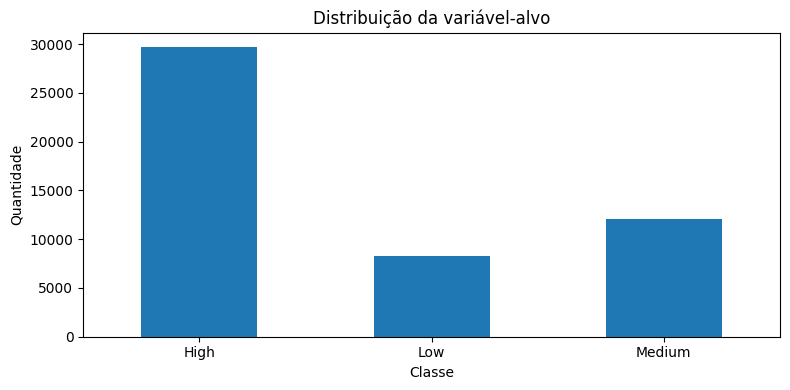

In [22]:
# distribuição da variável-alvo
target_col = "ev_adoption_likelihood"
target_counts = df_exp[target_col].value_counts().sort_index()
target_pct = (df_exp[target_col].value_counts(normalize=True).sort_index() * 100).round(2)
display(pd.DataFrame({"count": target_counts, "percentual": target_pct}))
plot_bar(target_counts, "Distribuição da variável-alvo", "Classe", "Quantidade")

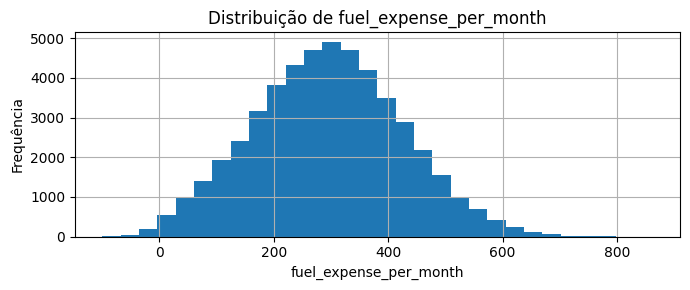

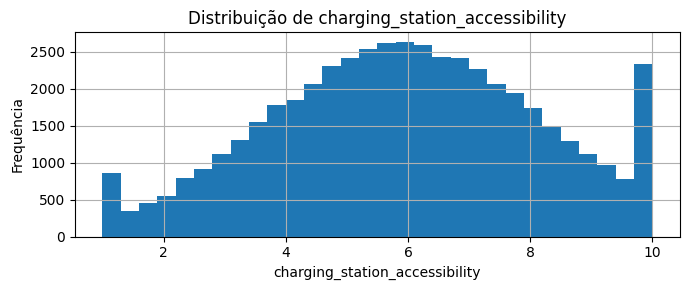

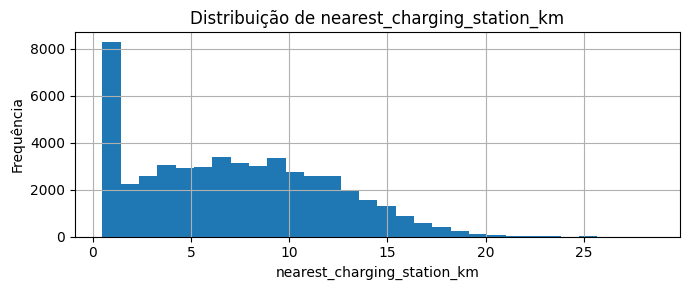

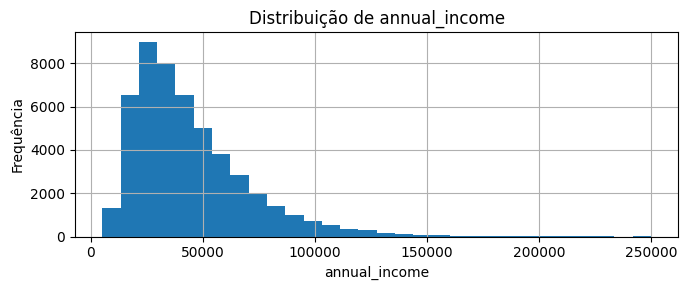

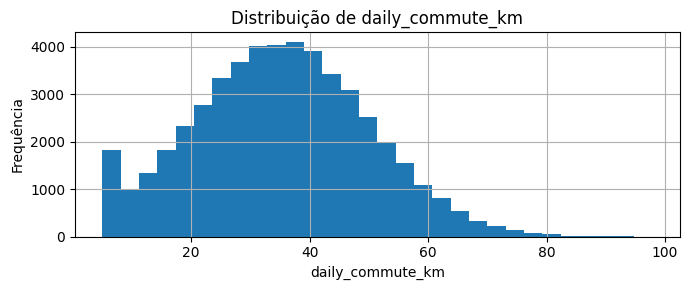

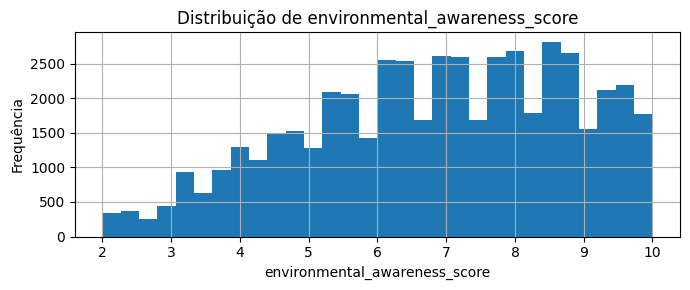

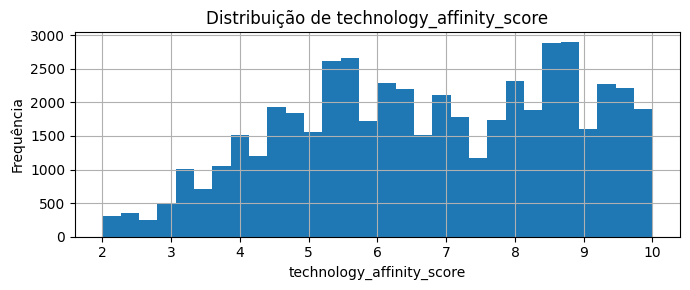

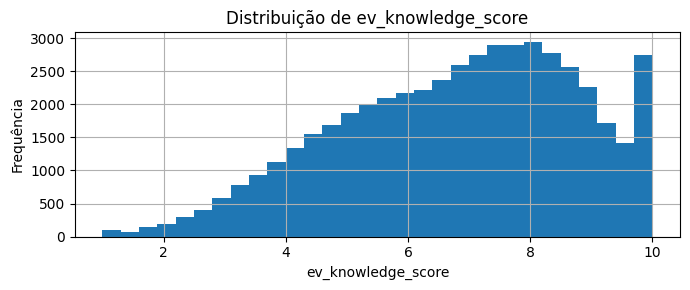

In [23]:
# distribuições de variáveis numéricas relevantes
important_numeric = [
    "fuel_expense_per_month",
    "charging_station_accessibility",
    "nearest_charging_station_km",
    "annual_income",
    "daily_commute_km",
    "environmental_awareness_score",
    "technology_affinity_score",
    "ev_knowledge_score",
]

for col in important_numeric:
    ax = df_exp[col].hist(bins=30, figsize=(7, 3))
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    plt.tight_layout()
    plt.show()

,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,annual_income,daily_commute_km,environmental_awareness_score,technology_affinity_score,ev_knowledge_score
ev_adoption_likelihood,,,,,,,,
High,295.43,6.18,6.74,52219.83,35.20,7.86,7.81,7.87
Low,294.43,5.14,8.15,29402.02,35.03,4.47,4.41,4.27
Medium,295.05,5.71,7.39,35072.49,35.18,5.92,5.62,5.72


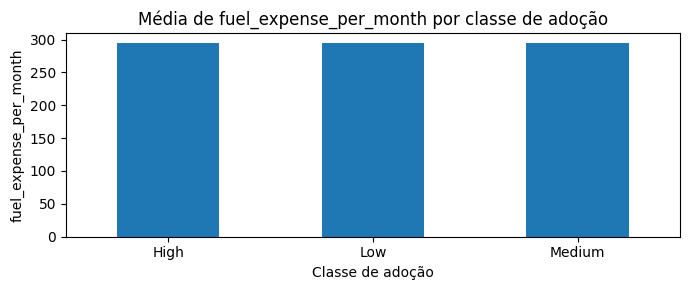

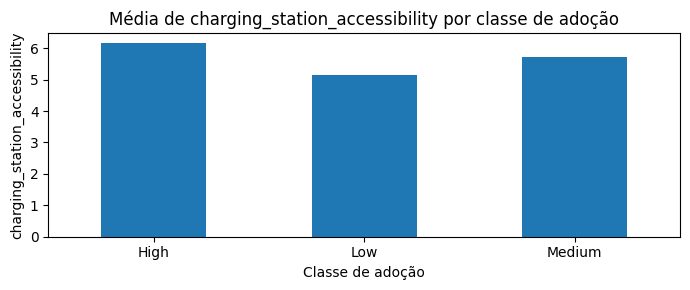

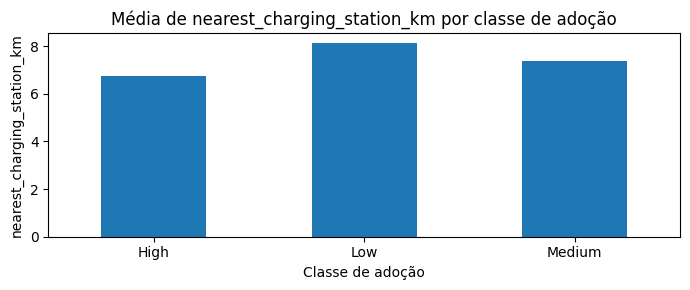

In [24]:
# médias de variáveis importantes por classe de adoção
eda_group = df_exp.groupby(target_col)[important_numeric].mean().round(2)
display(eda_group)

for col in ["fuel_expense_per_month", "charging_station_accessibility", "nearest_charging_station_km"]:
    ax = eda_group[col].plot(kind="bar", figsize=(7, 3))
    ax.set_title(f"Média de {col} por classe de adoção")
    ax.set_xlabel("Classe de adoção")
    ax.set_ylabel(col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

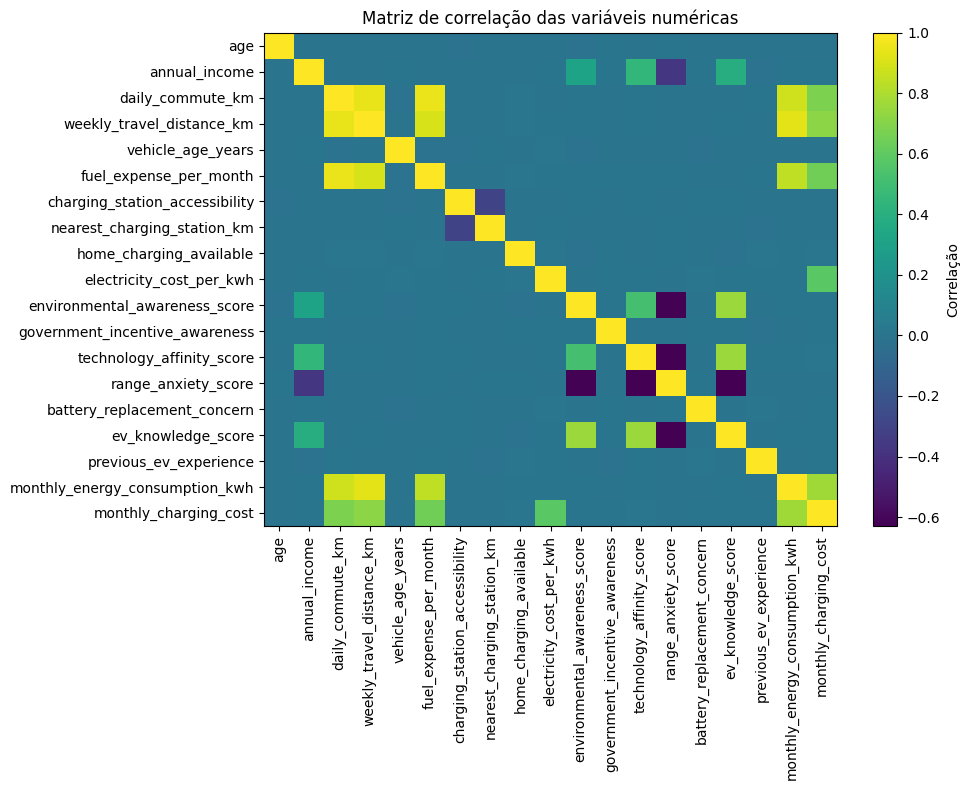

In [25]:
# correlação entre variáveis numéricas
numeric_cols = df_exp.select_dtypes(include=[np.number]).columns.tolist()
corr = df_exp[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlação")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

## 4.1 Observações da EDA

- O dataset contém variáveis numéricas e categóricas, exigindo pré-processamento específico para cada tipo.
- Há valores ausentes em algumas colunas, como `education_level`, `ev_knowledge_score` e `charging_station_accessibility`. Esses valores serão tratados dentro do pipeline para evitar vazamento de dados.
- A variável-alvo tem três classes, o que confirma a escolha de classificação multiclasse.
- As variáveis ligadas ao problema de negócio — gasto com combustível e infraestrutura de recarga — serão mantidas como preditores principais.

# 5. Preparação dos dados

Nesta etapa, as variáveis são separadas entre preditoras (`X`) e alvo (`y`). O pré-processamento será feito com `Pipeline` e `ColumnTransformer`, garantindo que imputação, padronização e codificação sejam ajustadas apenas nos dados de treino.

Tratamentos planejados:

- variáveis numéricas: imputação pela mediana e padronização;
- variáveis categóricas: imputação pela moda e One-Hot Encoding;
- variável-alvo: mantida como rótulo categórico para os classificadores;
- prevenção de vazamento: todas as transformações serão encapsuladas no pipeline.

In [27]:
"""
separação entre atributos e alvo para manter o MVP rápido e reprodutível em Colab, a modelagem usa uma amostra estratificada quando o dataset tiver muitos registros.
A EDA acima permanece feita sobre a base completa.
"""

MAX_MODEL_ROWS = 10000

if len(df_exp) > MAX_MODEL_ROWS:
    df_model, _ = train_test_split(
        df_exp,
        train_size=MAX_MODEL_ROWS,
        random_state=RANDOM_STATE,
        stratify=df[target_col]
    )
    print(f"Modelagem feita com amostra estratificada de {len(df_model):,} registros.")
else:
    df_model = df_exp.copy()
    print(f"Modelagem feita com a base completa de {len(df_model):,} registros.")

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Modelagem feita com amostra estratificada de 10,000 registros.
Variáveis numéricas: ['age', 'annual_income', 'daily_commute_km', 'weekly_travel_distance_km', 'vehicle_age_years', 'fuel_expense_per_month', 'charging_station_accessibility', 'nearest_charging_station_km', 'home_charging_available', 'electricity_cost_per_kwh', 'environmental_awareness_score', 'government_incentive_awareness', 'technology_affinity_score', 'range_anxiety_score', 'battery_replacement_concern', 'ev_knowledge_score', 'previous_ev_experience', 'monthly_energy_consumption_kwh', 'monthly_charging_cost']
Variáveis categóricas: ['education_level', 'city_type', 'current_vehicle_type']


# 6. Divisão dos dados

Como a tarefa é supervisionada, os dados serão divididos em treino e teste. A divisão será estratificada pela variável-alvo para preservar a proporção das classes nos dois conjuntos.

O conjunto de teste será usado apenas na avaliação final dos modelos, evitando uso indevido dos dados de teste durante treinamento e otimização.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)
print("\nDistribuição no treino:")
display(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True).sort_index().round(3))

Treino: (8000, 22) (8000,)
Teste: (2000, 22) (2000,)

Distribuição no treino:


,proportion
ev_adoption_likelihood,
High,0.593
Low,0.165
Medium,0.242



Distribuição no teste:


,proportion
ev_adoption_likelihood,
High,0.594
Low,0.165
Medium,0.242


# 7. Modelagem e treinamento

Serão avaliados os seguintes modelos:

1. **Baseline — DummyClassifier:** modelo ingênuo que prevê a classe mais frequente. Serve como referência mínima.
2. **Regressão Logística Multinomial:** modelo linear simples, interpretável e adequado como primeira abordagem supervisionada.
3. **Random Forest:** ensemble baseado em árvores, capaz de capturar relações não lineares e interações entre variáveis.
4. **Árvore de Decisão:** modelo simples e interpretável, útil para capturar relações não lineares com baixo custo computacional.

Todos os modelos usarão o mesmo pré-processamento para garantir comparação justa.

In [29]:
models = {
    "Baseline_Dummy": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
    ]),
    "Logistic_Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision_Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
    ]),
    "Random_Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=40, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1))
    ])
}

results = []
for name, model in models.items():
    print(f"Treinando {name}...")
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).drop(columns=["estimador"]).sort_values("f1_weighted_test", ascending=False)
display(results_df)

Treinando Baseline_Dummy...
Treinando Logistic_Regression...
Treinando Decision_Tree...
Treinando Random_Forest...


,modelo,accuracy_train,accuracy_test,f1_weighted_train,f1_weighted_test,tempo_treino_seg
1,Logistic_Regression,0.873000,0.8840,0.872839,0.882990,0.700044
3,Random_Forest,0.944750,0.8315,0.944572,0.829331,0.954680
2,Decision_Tree,0.869375,0.7915,0.870925,0.793679,0.150833
0,Baseline_Dummy,0.593375,0.5935,0.441947,0.442099,0.057245


## 7.1 Validação cruzada

Além da avaliação no conjunto de teste, será realizada validação cruzada estratificada no conjunto de treino. Isso permite observar a estabilidade dos modelos antes da avaliação final em dados não vistos.

In [30]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_weighted"],
        n_jobs=1,
        return_train_score=False
    )
    cv_rows.append({
        "modelo": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "cv_f1_weighted_std": scores["test_f1_weighted"].std()
    })

cv_df = pd.DataFrame(cv_rows).sort_values("cv_f1_weighted_mean", ascending=False)
display(cv_df)

,modelo,cv_accuracy_mean,cv_accuracy_std,cv_f1_weighted_mean,cv_f1_weighted_std
1,Logistic_Regression,0.868000,0.007010,0.867727,0.006741
3,Random_Forest,0.824375,0.002635,0.823234,0.003664
2,Decision_Tree,0.776501,0.005806,0.776590,0.004081
0,Baseline_Dummy,0.593375,0.000154,0.441947,0.000187


# 8. Otimização de hiperparâmetros

A otimização será aplicada ao modelo Random Forest, pois ele costuma se beneficiar de ajustes em profundidade, número de árvores e tamanho mínimo de folhas.

A estratégia escolhida é `RandomizedSearchCV`, que testa combinações de hiperparâmetros usando validação cruzada no conjunto de treino. O conjunto de teste permanece separado para avaliação final.

In [31]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_distributions = {
    "model__n_estimators": [30, 40, 60],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=3,
    scoring="f1_weighted",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)

start = time.time()
search.fit(X_train, y_train)
search_time = time.time() - start

print("Melhores hiperparâmetros:")
print(search.best_params_)
print(f"Melhor F1 weighted médio na validação cruzada: {search.best_score_:.4f}")
print(f"Tempo da busca: {search_time:.2f} segundos")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores hiperparâmetros:
{'model__n_estimators': 40, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Melhor F1 weighted médio na validação cruzada: 0.8232
Tempo da busca: 4.85 segundos


In [32]:
# avaliação do modelo otimizado no conjunto de teste
best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)

optimized_results = {
    "modelo": "Random_Forest_Otimizado",
    "accuracy_test": accuracy_score(y_test, y_pred_best),
    "f1_weighted_test": f1_score(y_test, y_pred_best, average="weighted")
}

comparison_final = pd.concat([
    results_df[["modelo", "accuracy_test", "f1_weighted_test"]],
    pd.DataFrame([optimized_results])
], ignore_index=True).sort_values("f1_weighted_test", ascending=False)

display(comparison_final)

,modelo,accuracy_test,f1_weighted_test
0,Logistic_Regression,0.8840,0.882990
1,Random_Forest,0.8315,0.829331
4,Random_Forest_Otimizado,0.8315,0.829331
2,Decision_Tree,0.7915,0.793679
3,Baseline_Dummy,0.5935,0.442099


# 9. Avaliação dos resultados

A avaliação final utiliza o conjunto de teste, que não foi usado para ajuste dos modelos. As métricas principais são:

- **Acurácia:** percentual total de classificações corretas;
- **F1-score weighted:** média ponderada do F1-score por classe, útil quando há diferença no tamanho das classes;
- **Matriz de confusão:** mostra onde o modelo acerta e erra entre as classes;
- **Relatório de classificação:** detalha precisão, recall e F1-score por classe.

Relatório de classificação — Random Forest Otimizado
              precision    recall  f1-score   support

        High       0.91      0.94      0.92      1187
         Low       0.79      0.73      0.76       330
      Medium       0.66      0.64      0.65       483

    accuracy                           0.83      2000
   macro avg       0.79      0.77      0.78      2000
weighted avg       0.83      0.83      0.83      2000



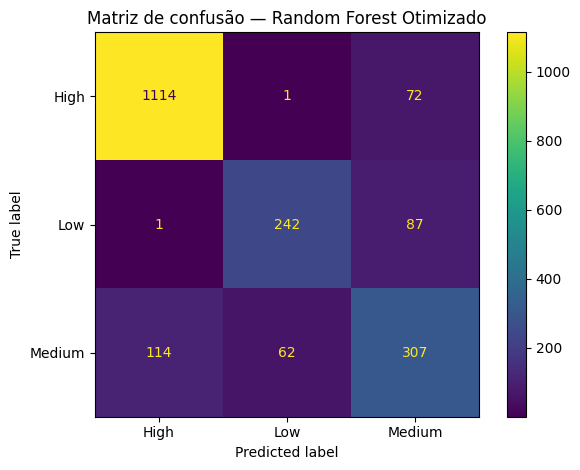

In [33]:
print("Relatório de classificação — Random Forest Otimizado")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(values_format="d")
plt.title("Matriz de confusão — Random Forest Otimizado")
plt.tight_layout()
plt.show()

In [34]:
# análise de overfitting/underfitting para o melhor modelo
train_pred_best = best_rf.predict(X_train)
fit_analysis = pd.DataFrame([{
    "modelo": "Random_Forest_Otimizado",
    "accuracy_train": accuracy_score(y_train, train_pred_best),
    "accuracy_test": accuracy_score(y_test, y_pred_best),
    "f1_weighted_train": f1_score(y_train, train_pred_best, average="weighted"),
    "f1_weighted_test": f1_score(y_test, y_pred_best, average="weighted")
}])
display(fit_analysis)

,modelo,accuracy_train,accuracy_test,f1_weighted_train,f1_weighted_test
0,Random_Forest_Otimizado,0.94475,0.8315,0.944572,0.829331


## 9.1 Importância das variáveis

Para interpretar o modelo, será calculada a importância por permutação no conjunto de teste. Essa técnica mede a queda de desempenho quando os valores de uma variável são embaralhados, indicando o quanto ela contribui para a previsão.

Como o dataset possui variáveis categóricas codificadas, a interpretação é feita no nível das colunas após o pré-processamento.

,feature,importance_mean,importance_std
16,range_anxiety_score,0.095190,0.003136
18,ev_knowledge_score,0.079593,0.002118
13,environmental_awareness_score,0.056053,0.005509
15,technology_affinity_score,0.030261,0.002066
9,charging_station_accessibility,0.012374,0.003193
14,government_incentive_awareness,0.006803,0.006592
5,weekly_travel_distance_km,0.005416,0.000653
10,nearest_charging_station_km,0.001976,0.002124
11,home_charging_available,0.001887,0.002013
17,battery_replacement_concern,0.001499,0.001166


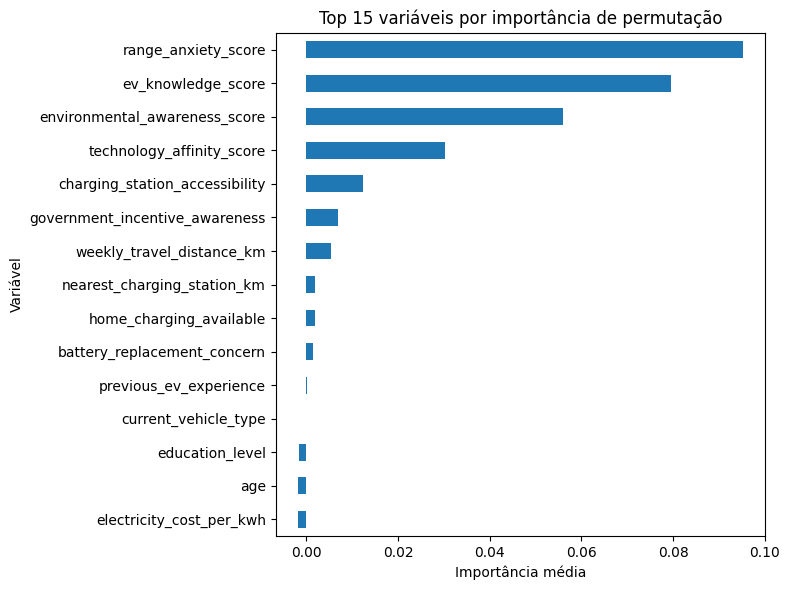

In [35]:
"""
importância por permutação no conjunto de teste. para manter o tempo de execução razoável, usa-se uma amostra do teste se ele for muito grande.
"""
if len(X_test) > 800:
    X_perm = X_test.sample(800, random_state=RANDOM_STATE)
    y_perm = y_test.loc[X_perm.index]
else:
    X_perm = X_test
    y_perm = y_test

perm = permutation_importance(
    best_rf,
    X_perm,
    y_perm,
    n_repeats=2,
    random_state=RANDOM_STATE,
    scoring="f1_weighted",
    n_jobs=1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(15))

ax = importance_df.head(15).set_index("feature")["importance_mean"].sort_values().plot(kind="barh", figsize=(8, 6))
ax.set_title("Top 15 variáveis por importância de permutação")
ax.set_xlabel("Importância média")
ax.set_ylabel("Variável")
plt.tight_layout()
plt.show()

## 9.2 Discussão dos resultados

A comparação entre o baseline e os modelos candidatos permite verificar se os modelos realmente aprenderam padrões úteis. O baseline representa uma regra ingênua e deve ser superado para que o MVP tenha valor preditivo.

A análise de treino versus teste ajuda a identificar overfitting ou underfitting:

- se o desempenho de treino for muito maior que o de teste, há sinal de overfitting;
- se ambos forem baixos, há sinal de underfitting ou limitação dos atributos;
- se ambos forem próximos e superiores ao baseline, o modelo tende a generalizar melhor.

A importância das variáveis também ajuda a conectar os resultados ao problema de negócio, verificando se fatores como gasto com combustível e infraestrutura de recarga aparecem entre os atributos relevantes.

In [36]:
# síntese automática dos principais resultados para apoiar a conclusão textual
best_row = comparison_final.iloc[0]
baseline_row = comparison_final[comparison_final["modelo"] == "Baseline_Dummy"].iloc[0]

print(f"Melhor modelo: {best_row['modelo']}")
print(f"F1 weighted do melhor modelo no teste: {best_row['f1_weighted_test']:.4f}")
print(f"F1 weighted do baseline no teste: {baseline_row['f1_weighted_test']:.4f}")
print(f"Ganho absoluto de F1 weighted vs baseline: {best_row['f1_weighted_test'] - baseline_row['f1_weighted_test']:.4f}")
print("\nTop 10 variáveis por importância:")
print(importance_df.head(10).to_string(index=False))

Melhor modelo: Logistic_Regression
F1 weighted do melhor modelo no teste: 0.8830
F1 weighted do baseline no teste: 0.4421
Ganho absoluto de F1 weighted vs baseline: 0.4409

Top 10 variáveis por importância:
                       feature  importance_mean  importance_std
           range_anxiety_score         0.095190        0.003136
            ev_knowledge_score         0.079593        0.002118
 environmental_awareness_score         0.056053        0.005509
     technology_affinity_score         0.030261        0.002066
charging_station_accessibility         0.012374        0.003193
government_incentive_awareness         0.006803        0.006592
     weekly_travel_distance_km         0.005416        0.000653
   nearest_charging_station_km         0.001976        0.002124
       home_charging_available         0.001887        0.002013
   battery_replacement_concern         0.001499        0.001166


# 10. Conclusão do MVP

Este MVP abordou o problema de prever a propensão de adoção de veículos elétricos a partir de fatores econômicos, comportamentais e de infraestrutura. A variável-alvo utilizada foi `ev_adoption_likelihood`, composta pelas classes `Low`, `Medium` e `High`, caracterizando uma tarefa de classificação multiclasse.

O dataset utilizado contém 50.000 registros e 23 atributos relacionados a renda, deslocamento, tipo e idade do veículo, gasto com combustível, custo de eletricidade, disponibilidade de recarga, distância até estação de recarga, consciência ambiental, conhecimento sobre veículos elétricos e afinidade tecnológica.

Foram realizados tratamentos de dados ausentes, padronização de variáveis numéricas e codificação de variáveis categóricas por meio de pipelines, reduzindo o risco de vazamento de dados. A divisão treino/teste foi estratificada para preservar a distribuição da variável-alvo.

Foram avaliados um modelo baseline e três modelos candidatos: Regressão Logística, Árvore de Decisão e Random Forest. Além disso, foi realizada otimização de hiperparâmetros para Random Forest com `RandomizedSearchCV` usando validação cruzada.

A escolha da melhor solução deve considerar o desempenho no conjunto de teste, especialmente o F1-score weighted, e a diferença entre desempenho de treino e teste. Caso o modelo otimizado supere o baseline e mantenha desempenho semelhante entre treino e teste, ele pode ser considerado uma solução inicial adequada para o MVP.

## Limitações

- O dataset aparenta ser sintético ou simulado, o que pode limitar a generalização para cenários reais.
- A variável-alvo representa propensão declarada ou estimada de adoção, não necessariamente adoção real observada.
- O modelo não considera fatores macroeconômicos externos, como preço real de veículos elétricos, políticas públicas por país, renda regional, impostos, disponibilidade de modelos no mercado ou preço histórico dos combustíveis.
- A análise é tabular e estática, sem componente temporal.

## Próximos passos

- Substituir o carregamento local por uma URL RAW pública funcional no GitHub.
- Validar o modelo com dados reais de mercado, caso disponíveis.
- Testar modelos adicionais, como XGBoost, LightGBM ou CatBoost.
- Criar variáveis derivadas, como razão entre gasto com combustível e renda, ou índice combinado de infraestrutura de recarga.
- Avaliar explicabilidade com técnicas como SHAP para aprofundar a interpretação das variáveis.
- Transformar o modelo em um protótipo simples de apoio à decisão para simular cenários de aumento de preço de combustível ou expansão da rede de recarga.

# 11. Respostas ao checklist do MVP

**Qual é a descrição do problema?**  
Prever a propensão de adoção de veículos elétricos com base em fatores econômicos, comportamentais e de infraestrutura.

**Qual é o objetivo do modelo?**  
Classificar cada registro em baixa, média ou alta propensão de adoção de veículo elétrico.

**O problema é de classificação, regressão, clusterização ou séries temporais?**  
Classificação multiclasse supervisionada.

**Por que pode ser resolvido com Machine Learning?**  
Porque há atributos explicativos e uma variável-alvo conhecida, permitindo que algoritmos aprendam padrões nos dados.

**Qual dataset foi utilizado?**  
`global_ev_adoption_behavior_2026.csv`.

**Existe variável-alvo?**  
Sim, `ev_adoption_likelihood`.

**Houve valores ausentes? Como foram tratados?**  
Sim. Variáveis numéricas foram imputadas pela mediana e variáveis categóricas pela moda, dentro do pipeline.

**Foram aplicadas normalização, padronização ou codificação?**  
Sim. Variáveis numéricas foram padronizadas e variáveis categóricas foram codificadas com One-Hot Encoding.

**Houve preocupação com vazamento de dados?**  
Sim. As transformações foram ajustadas apenas no conjunto de treino por meio de pipelines.

**Como os dados foram separados?**  
Divisão treino/teste com 80% para treino e 20% para teste, usando estratificação pela variável-alvo.

**Qual foi o baseline?**  
`DummyClassifier` com estratégia de classe mais frequente.

**Quais modelos foram treinados?**  
Regressão Logística, Árvore de Decisão e Random Forest, além do baseline.

**Algum modelo teve hiperparâmetros ajustados?**  
Sim. Random Forest foi otimizado com `RandomizedSearchCV`.

**Quais métricas foram utilizadas?**  
Acurácia, F1-score weighted, matriz de confusão e relatório de classificação.

**Quais são as principais limitações?**  
Possível natureza sintética dos dados, ausência de variáveis macroeconômicas e falta de validação com dados reais de adoção.